# MM Kinetic Analysis
## Bryan

In [1]:
import pandas as pd
import math
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.optimize import curve_fit
import matplotlib.cm as cm


## MM Functions

In [2]:
class KineticDataException(Exception):
    pass

In [3]:
def divide_chunks(l, n):
    n = math.ceil(len(l) / float(n))
    for i in range(0, len(l), n):
        yield l[i:i + n]

In [4]:
def compute_initial_reaction_slope(time_arr: np.array, 
                                   signal_arr: np.array,
                                  min_included_percent: int = 5): 
    """
    Determines best linear fit to initial slope of data, by fitting regressions to 
    all percentiles of the data--greater than some defined minimum--anchored at the origin.
    
    Args:
        time_arr (np.array): array of assay read times
        signal_arr (np.array): array of kinetic signal readouts
        min_included_percent (int) = 5: minimum percent of data to be included 
    
    Returns:
        slope, intercept, score ((float, float, float)): fit parameters of best fit
        
    """
    # Need to triage further for different definitions of minimum
    MIN_INCLUDED_DATA_POINTS = 5
    
    perc_concs = list(divide_chunks(signal_arr, 100))
    perc_times = list(divide_chunks(time_arr, 100))
 
    scores = []
    slopes = [] 
    intercepts = []
    
    min_inclusion = max(len(perc_times) * min_included_percent // 100, 5)
    
    for i in range(len(perc_times), min_inclusion, -1):
        curr_times = np.concatenate(perc_times[:i])
        curr_concs = np.concatenate(perc_concs[:i])
        #curr_times = [item for sublist in perc_times[:i] for item in sublist]
        #curr_concs = [item for sublist in perc_concs[:i] for item in sublist]
        
        reg = LinearRegression().fit(np.array(curr_times).reshape(-1,1), curr_concs)
        curr_score = reg.score(np.array(curr_times).reshape(-1,1), curr_concs)
        scores.append(curr_score)
        slopes.append(reg.coef_)
        intercepts.append(reg.intercept_)
    
    if len(scores) == 0 and min_included_percent == 100:
        reg = LinearRegression().fit(np.array(perc_times).reshape(-1,1), perc_concs)
        curr_score = reg.score(np.array(perc_times).reshape(-1,1), perc_concs)
        return reg.coef_.item(), reg.intercept_.item(), curr_score
    
    max_r2_idx = np.argmax(scores)
    
    if scores[max_r2_idx] < 0.9:
        return np.array([np.nan]), np.array([np.nan]), np.array([np.nan])
        #return float('nan'), float('nan'), float('nan')
    return slopes[max_r2_idx], intercepts[max_r2_idx], scores[max_r2_idx]


In [5]:
def get_initial_slopes(time_arr: np.array, kinetic_data: np.array, plot: bool = False,
                       substrate_concs: [int] = None, 
                       title: str = None, fig_size: (int, int) = (10,10), triage: bool = False):
    
    if plot and (substrate_concs is None or title is None):
        raise KineticDataException("Plotting initial slopes requires substratce concentration and titles")
    
    slopes = []
    intercepts = []
    scores = []
    
    for data in kinetic_data:
        slope, intercept, score = compute_initial_reaction_slope(time_arr, data)
        slopes.append(slope)
        intercepts.append(intercept)
        scores.append(score)
        
    if plot:
       
        fig = plt.figure(figsize=fig_size) 
        
        for data in kinetic_data:
            plt.scatter(time_arr, data)
        x = np.linspace(min(time_arr), max(time_arr), 1000)
       
        x_tiled = np.tile(x,(len(substrate_concs),1)).T
        plt.plot(x_tiled,
                 x_tiled * np.array(slopes).T + np.array(intercepts).T,
                 linewidth=3, label=[f"{sub_conc:.2f} µM" for sub_conc in substrate_concs])
        plt.title(title)
        plt.xlabel("Time (seconds)")
        plt.ylabel("µM")
        plt.legend() 
    
        if triage:

            fig, axs = plt.subplots(math.ceil(len(sub_concs) / 2), 2, figsize=(15,15))

            for ax, data, slope, intercept, sub_conc in zip(axs.flat, kinetic_data, slopes, intercepts, substrate_concs):
                ax.scatter(time_arr, data)
                ax.set_title(f"{sub_conc:.2f} µM")
                ax.plot(x, x * slope + intercept)
           
    return np.concatenate(slopes)

In [6]:
def mm_model(x, v_max, Km):
    return v_max * x / (x + Km)

In [39]:
def fit_and_plot_micheaelis_menten(rep_1_slopes: np.array, rep_2_slopes: np.array, sub_concs: [int], e_conc: float, title: str, background_rates: np.array = None):
    avg_slopes = np.nanmean([rep_1_slopes, rep_2_slopes], axis=0)[..., np.newaxis]
   
    if background_rates is not None:
        avg_slopes -= background_rates
    errs = np.nanstd([rep_1_slopes, rep_2_slopes], axis=0) 
    params, _ = curve_fit(mm_model, sub_concs, np.concatenate(avg_slopes))
    
    plt.figure(figsize=(10,6))

    plt.scatter(sub_concs, avg_slopes/e_conc)
    plt.errorbar(sub_concs, np.concatenate(avg_slopes/e_conc), yerr=(errs/e_conc).T, fmt="o", capsize=5)
    x = np.linspace(0, 4000, 1000)
    plt.plot(x, mm_model(x, params[0], params[1]) / e_conc)
    plt.xlabel("[S] (µM)")
    plt.ylabel("v ($s^{-1}$)")
    plt.title(title + " kinetics: $k_{cat}$ = " +f"{params[0] / e_conc:.0f}" + " $s^{-1}$ " + f"  $K_m$ = {params[1]:.0f} µM")

# Data Cleaning and Prep

In [8]:
df = pd.read_csv("../data/20220719_bryan_nadph_adk_kinetics.csv", header=0)

In [9]:
df.head()

,Time [s],Temp. [°C],L1,L2,L4,L6,L8,L10,L12,L14,M1,M2,M4,M6,M8,M10,M12,M14
0,0.000,30.0,5772,8655,6580,5413,4240,2565,1969,1470,153,8202,11458,4058,4621,2809,2205,2755
1,14.281,30.1,5920,8733,6667,5569,4583,2642,2024,1543,151,8283,11938,4118,4886,2967,2278,2867
2,29.280,30.1,5898,8767,6705,5601,4501,2371,2021,1535,146,8487,12616,4320,5269,3050,2388,2950
3,44.281,30.1,5855,8945,6874,5739,4685,2541,2034,1502,148,8634,12969,4407,5394,3189,2457,2962
4,59.287,30.1,6031,8958,6932,5865,4688,2544,2054,1532,153,8739,13563,4551,5699,3281,2547,2976


In [10]:
time_arr = np.array(df["Time [s]"])

In [11]:
time_arr.shape

(480,)

The shape of the time array indicates our expected number of signal readings ^ so the second dimension of all our subsequent arrays should match this.

# Computing Background Rates

In [12]:
RFU_TO_NADPH_CONVERSION_FACTOR = 179

In this case, the wells are indicated by columns, and I am looking for wells [J1:J16]

We need to transpose our array as our desired time count dimension is currently the first dimension.

I did my replicates next to each other along the row, so J1==J2, J3==J4 etc.,
so now I need to separate by replicates.

# gsADK I111L Data

In [17]:
bs_df = df.iloc[:, 3:10]
bs_arr = np.array(bs_df).T / RFU_TO_NADPH_CONVERSION_FACTOR # convert to uM NADPH

In [48]:
bs_conc = .519 /2000

In [ ]:
sub_concs = [3, 1.5, .75, .375, .1875, .09375, .046875] 

In [ ]:
sub_concs = [conc * 1000 for conc in sub_concs]

In [ ]:
sub_concs

[3000, 1500.0, 750.0, 375.0, 187.5, 93.75, 46.875]

## Scatter Plot Data

Text(0, 0.5, '[NADPH] (µM')

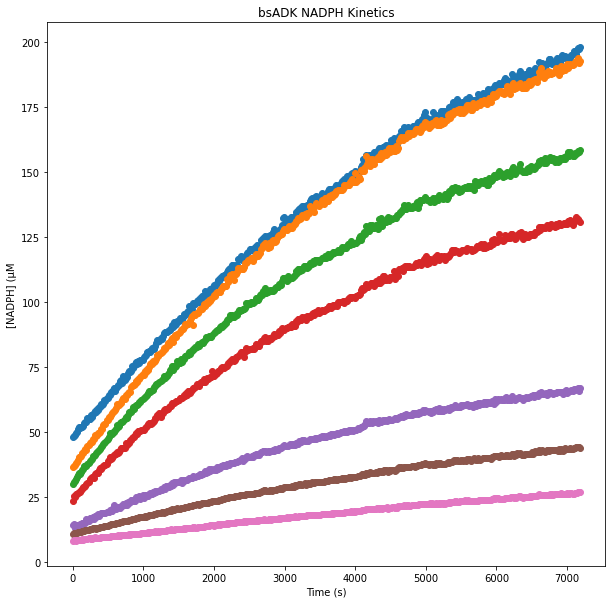

In [19]:
fig = plt.figure(figsize=(10,10))

for data in bs_arr:
    plt.scatter(time_arr, data)
plt.title("bsADK NADPH Kinetics")
plt.xlabel("Time (s)")
plt.ylabel("[NADPH] (µM")

TODO: add some triage functionality to show poor fit on rep 1

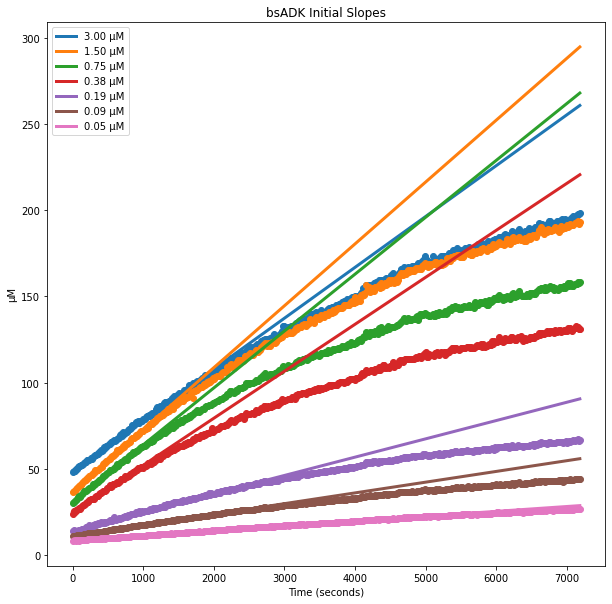

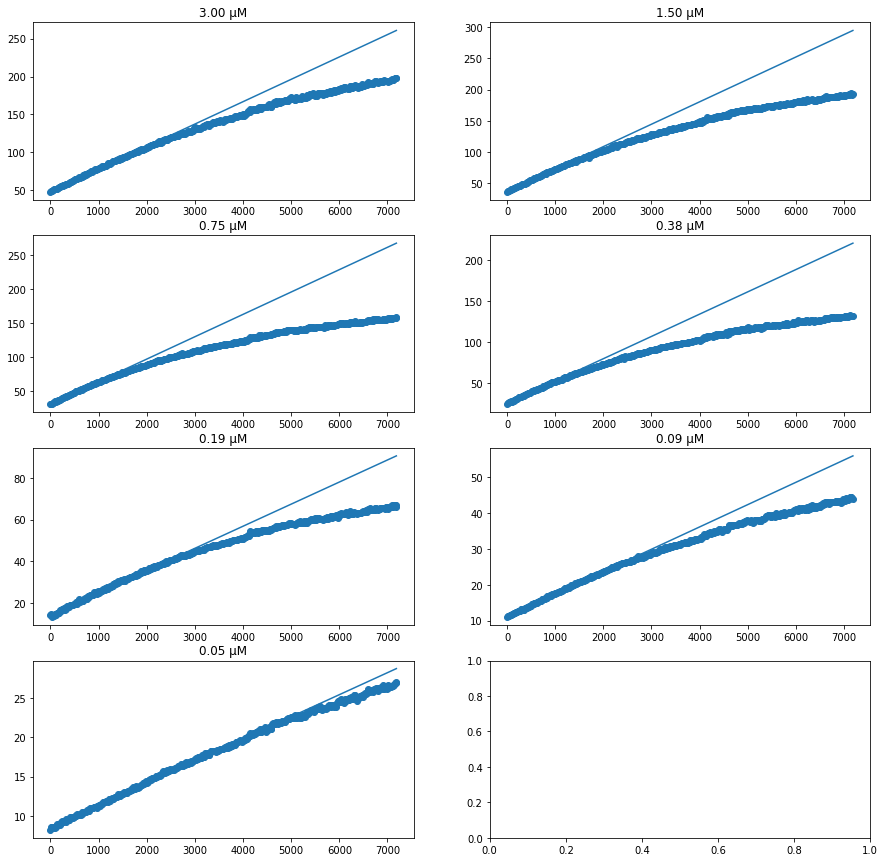

In [22]:
#gsADK_i111l_r1_slopes = get_initial_slopes(time_arr, gs_i111l_rep_1_arr)
bsADK_slopes = get_initial_slopes(time_arr, bs_arr, 
                                           plot=True, substrate_concs=sub_concs,
                                           title="bsADK Initial Slopes", triage=True)

In [23]:
bsADK_slopes

array([0.02947452, 0.03586349, 0.03297391, 0.02723149, 0.0106074 ,
       0.00622537, 0.00281047])

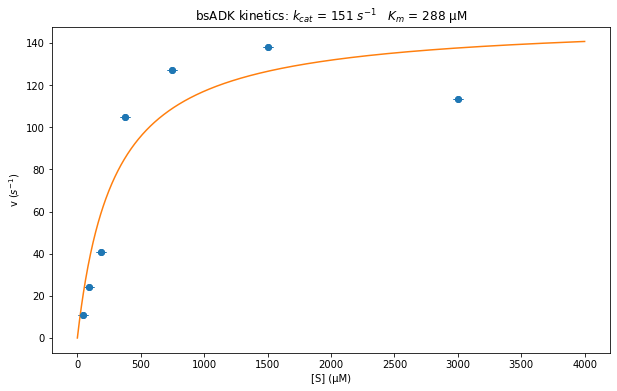

In [49]:
fit_and_plot_micheaelis_menten(np.array(bsADK_slopes), np.array(bsADK_slopes), sub_concs, 
                               bs_conc, "bsADK")

Cut off initial rxn data when flat/artifcact

# gsADK

In [53]:
gs_df = df.iloc[:, 11:18]
gs_arr = np.array(gs_df).T / RFU_TO_NADPH_CONVERSION_FACTOR # convert to uM NADPH

In [54]:
gs_conc = .497 /2000

In [55]:
sub_concs

[3000, 1500.0, 750.0, 375.0, 187.5, 93.75, 46.875]

## Scatter Plot Data

Text(0, 0.5, '[NADPH] (µM')

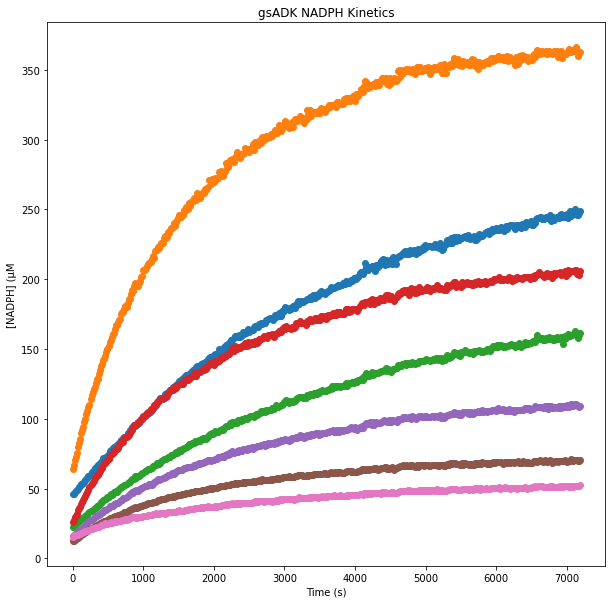

In [56]:
fig = plt.figure(figsize=(10,10))

for data in gs_arr:
    plt.scatter(time_arr, data)
plt.title("gsADK NADPH Kinetics")
plt.xlabel("Time (s)")
plt.ylabel("[NADPH] (µM")

TODO: add some triage functionality to show poor fit on rep 1

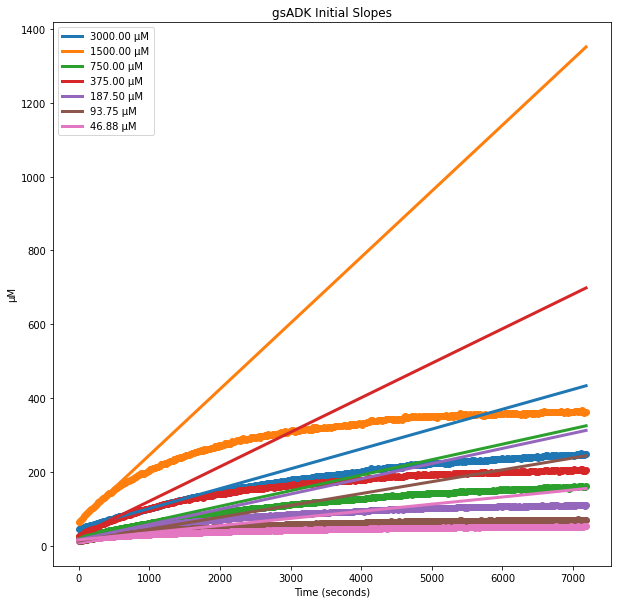

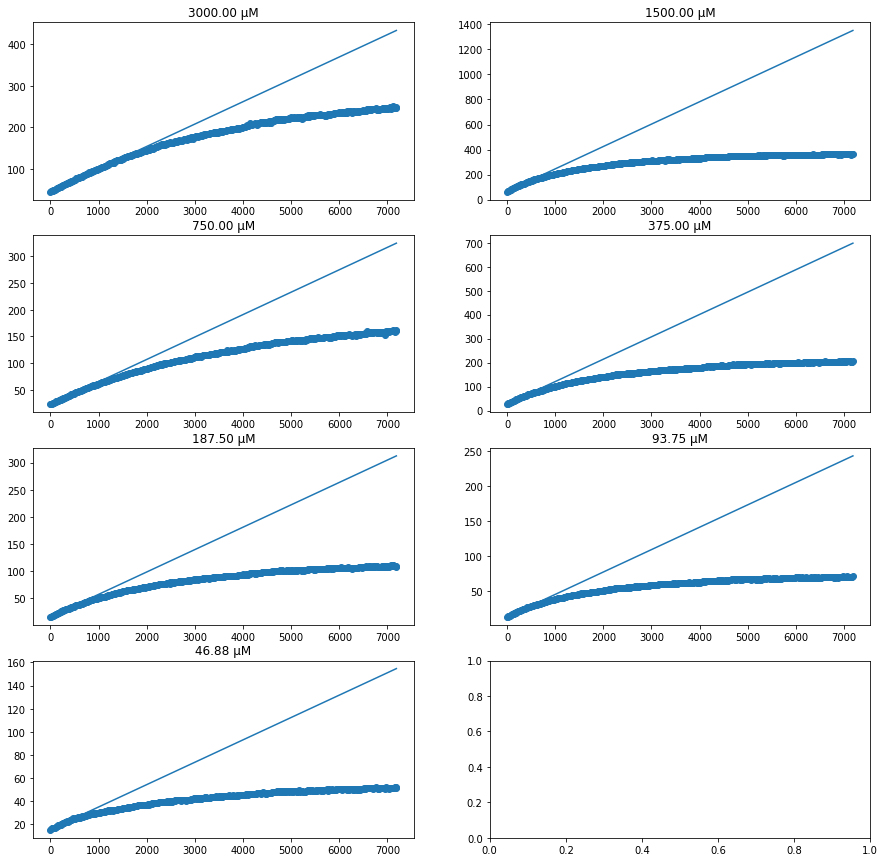

In [57]:
#gsADK_i111l_r1_slopes = get_initial_slopes(time_arr, gs_i111l_rep_1_arr)
gsADK_slopes = get_initial_slopes(time_arr, gs_arr, 
                                           plot=True, substrate_concs=sub_concs,
                                           title="gsADK Initial Slopes", triage=True)

In [58]:
gsADK_slopes

array([0.05378318, 0.17885862, 0.04203619, 0.09342463, 0.04120057,
       0.03213508, 0.01934027])

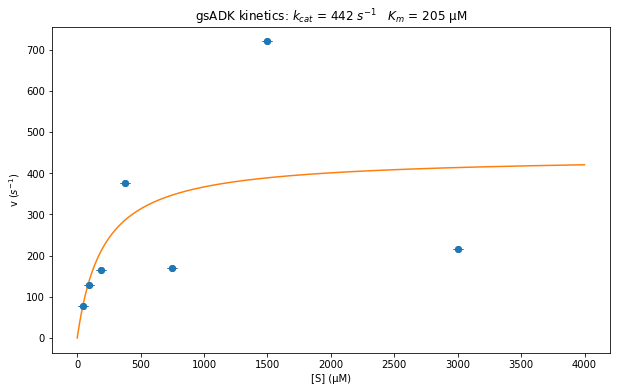

In [59]:
fit_and_plot_micheaelis_menten(np.array(gsADK_slopes), np.array(gsADK_slopes), sub_concs, 
                               gs_conc, "gsADK")